In [2]:
# Cell 1: imports and settings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import ast, os, pickle, random
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity as cs
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
print("Libraries loaded.")


Libraries loaded.


In [5]:
# Cell 2: load datasets (paths reflect your uploaded files)
movies_path = r"C:\Users\DELL\Desktop\Personalized_Recommendation_System\data\tmdb_5000_movies.csv"
credits_path = r"C:\Users\DELL\Desktop\Personalized_Recommendation_System\data\tmdb_5000_credits.csv"

movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

# Merge credits into movies (credits has movie_id -> rename to id)
credits = credits.rename(columns={"movie_id":"id"})
movies_merged = movies.merge(credits, on="id", how="left", suffixes=('','_credits'))

print("movies:", movies.shape, "credits:", credits.shape, "merged:", movies_merged.shape)
display(movies_merged.head(3))


movies: (4803, 20) credits: (4803, 4) merged: (4803, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,title_credits,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [6]:
# Cell 3: parse the JSON-like columns and extract director, cast, genres, keywords
import ast

def parse_col(x):
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

for col in ['genres','keywords','cast','crew']:
    if col in movies_merged.columns:
        movies_merged[col] = movies_merged[col].fillna('[]').apply(parse_col)

def get_director(crew):
    for person in crew:
        if person.get('job') == 'Director':
            return person.get('name')
    return None

def top_n(lst, n=3, key='name'):
    if not isinstance(lst, list):
        return []
    return [item.get(key) for item in lst[:n]]

movies_merged['director'] = movies_merged['crew'].apply(get_director)
movies_merged['cast_names'] = movies_merged['cast'].apply(lambda x: top_n(x,3,'name'))
movies_merged['genre_names'] = movies_merged['genres'].apply(lambda x: [g.get('name') for g in x])
movies_merged['keyword_names'] = movies_merged['keywords'].apply(lambda x: [k.get('name') for k in x])

# Create a "soup" (combined text field) for content-based TF-IDF
def clean_list(l):
    if not isinstance(l, list):
        return []
    return [str(i).replace(" ", "").lower() for i in l]

movies_merged['soup'] = movies_merged['genre_names'].apply(clean_list) \
                        + movies_merged['cast_names'].apply(clean_list) \
                        + movies_merged['keyword_names'].apply(clean_list) \
                        + movies_merged['director'].fillna('').apply(lambda d: [d.replace(" ", "").lower()] if d else []) \
                        + movies_merged['overview'].fillna('').apply(lambda x: [w for w in x.lower().split()[:50]])

movies_merged['soup_text'] = movies_merged['soup'].apply(lambda x: " ".join(x))
display(movies_merged[['title','director','cast_names','genre_names','soup_text']].head(3))


,title,director,cast_names,genre_names,soup_text
0,Avatar,James Cameron,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[Action, Adventure, Fantasy, Science Fiction]",action adventure fantasy sciencefiction samwor...
1,Pirates of the Caribbean: At World's End,Gore Verbinski,"[Johnny Depp, Orlando Bloom, Keira Knightley]","[Adventure, Fantasy, Action]",adventure fantasy action johnnydepp orlandoblo...
2,Spectre,Sam Mendes,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[Action, Adventure, Crime]",action adventure crime danielcraig christophwa...


Unique titles: 4800
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'title_credits', 'cast', 'crew', 'director', 'cast_names', 'genre_names', 'keyword_names', 'soup', 'soup_text']


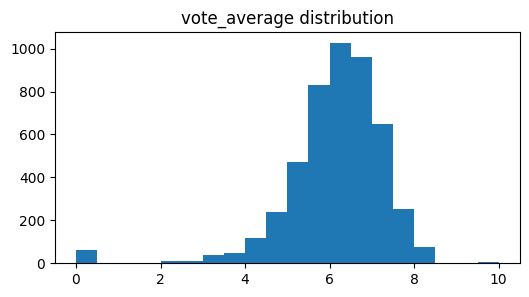

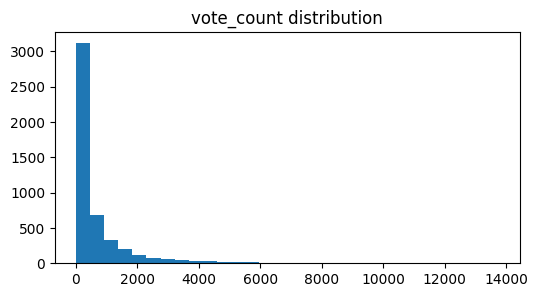

,title,vote_count,vote_average
96,Inception,13752,8.1
65,The Dark Knight,12002,8.2
0,Avatar,11800,7.2
16,The Avengers,11776,7.4
788,Deadpool,10995,7.4
95,Interstellar,10867,8.1
287,Django Unchained,10099,7.8
94,Guardians of the Galaxy,9742,7.9
426,The Hunger Games,9455,6.9
127,Mad Max: Fury Road,9427,7.2


In [7]:
# Cell 4: quick EDA
print("Unique titles:", movies_merged['title'].nunique())
print("Columns:", movies_merged.columns.tolist())

# vote distribution
plt.figure(figsize=(6,3))
plt.hist(movies_merged['vote_average'].fillna(0), bins=20)
plt.title("vote_average distribution")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(movies_merged['vote_count'].fillna(0), bins=30)
plt.title("vote_count distribution")
plt.show()

# Top 10 movies by vote_count
display(movies_merged[['title','vote_count','vote_average']].sort_values('vote_count', ascending=False).head(10))


In [8]:
# Cell 5: TF-IDF on the 'soup_text' and cosine similarity
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies_merged['soup_text'].fillna(''))

# cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# mapping title -> index
title_to_index = pd.Series(movies_merged.index, index=movies_merged['title']).drop_duplicates()

def get_content_recommendations(title, topn=10):
    if title not in title_to_index:
        return []
    idx = title_to_index[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:topn+1]
    indices = [i[0] for i in sim_scores]
    return movies_merged['title'].iloc[indices].tolist()

# demo
sample_title = movies_merged['title'].iloc[5]
print("Sample:", sample_title)
print(get_content_recommendations(sample_title, topn=8))


Sample: Spider-Man 3
['Spider-Man 2', 'Spider-Man', 'Arachnophobia', 'The Amazing Spider-Man 2', "Charlotte's Web", "Cirque du Freak: The Vampire's Assistant", 'The Amazing Spider-Man', 'Jungle Shuffle']


In [9]:
# Cell 6: create a synthetic user-item rating dataset
NUM_USERS = 500       # change as you like
RATINGS_PER_USER = 25

np.random.seed(42)
movie_indices = list(movies_merged.index)
pop = (movies_merged['vote_count'].fillna(0).values + 1).astype(float)
pop = pop / pop.sum()

rows = []
for user in range(NUM_USERS):
    sampled = np.random.choice(movie_indices, size=RATINGS_PER_USER, replace=False, p=pop)
    for m in sampled:
        base = movies_merged.at[m,'vote_average'] if not np.isnan(movies_merged.at[m,'vote_average']) else 6.0
        base_rating = np.clip((base/10)*5, 1, 5)
        rating = np.clip(base_rating + np.random.normal(0, 0.8), 1, 5)
        rows.append((user, m, rating))

ratings_df = pd.DataFrame(rows, columns=['user_id','movie_idx','rating'])
print("Simulated ratings count:", len(ratings_df))
display(ratings_df.head())


Simulated ratings count: 12500


,user_id,movie_idx,rating
0,0,511,3.454023
1,0,3789,2.160201
2,0,2015,2.914494
3,0,1340,3.488738
4,0,124,2.729205


In [10]:
# Cell 7: pivot to user-item
user_item = ratings_df.pivot(index='user_id', columns='movie_idx', values='rating').fillna(0)
print("user_item shape:", user_item.shape)

# user similarity (cosine)
user_sim = cs(user_item.values)
item_sim = cs(user_item.T.values)

def user_based_recommendations(user_id, topn=10):
    if user_id not in user_item.index:
        return []
    sim = user_sim[user_id]
    weighted = sim.dot(user_item.values) / (np.abs(sim).sum() + 1e-9)
    pred = pd.Series(weighted, index=user_item.columns)
    already = user_item.loc[user_id] > 0
    pred = pred[~already]
    top = pred.sort_values(ascending=False).head(topn).index.tolist()
    return movies_merged['title'].iloc[top].tolist()

def item_based_recommendations_for_user(user_id, topn=10):
    user_ratings = user_item.loc[user_id].values
    scores = item_sim.dot(user_ratings) / (np.abs(item_sim).sum(axis=1) + 1e-9)
    pred = pd.Series(scores, index=user_item.columns)
    already = user_item.loc[user_id] > 0
    pred = pred[~already]
    top = pred.sort_values(ascending=False).head(topn).index.tolist()
    return movies_merged['title'].iloc[top].tolist()

# Demo
print("UBCF (user 0):", user_based_recommendations(0, topn=6))
print("IBCF (user 0):", item_based_recommendations_for_user(0, topn=6))


user_item shape: (500, 2671)
UBCF (user 0): ['The Dark Knight', 'Iron Man', 'Avatar', 'Fight Club', 'The Avengers', 'Inception']
IBCF (user 0): ['Quartet', '40 Days and 40 Nights', '2046', 'Speed Racer', 'Wild Target', 'Biutiful']


In [11]:
# Cell 8: matrix factorization with TruncatedSVD and NMF
n_components = 20
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(user_item.values)
item_factors = svd.components_.T
pred_svd = np.dot(user_factors, item_factors.T)
pred_df_svd = pd.DataFrame(pred_svd, index=user_item.index, columns=user_item.columns)

def svd_recommendations(user_id, topn=10):
    if user_id not in pred_df_svd.index:
        return []
    preds = pred_df_svd.loc[user_id]
    preds = preds[user_item.loc[user_id] == 0]
    top = preds.sort_values(ascending=False).head(topn).index.tolist()
    return movies_merged['title'].iloc[top].tolist()

# NMF
nmf = NMF(n_components=15, init='nndsvda', random_state=42, max_iter=400)
W = nmf.fit_transform(user_item.values)
H = nmf.components_
pred_nmf = np.dot(W, H)
pred_df_nmf = pd.DataFrame(pred_nmf, index=user_item.index, columns=user_item.columns)

def nmf_recommendations(user_id, topn=10):
    if user_id not in pred_df_nmf.index:
        return []
    preds = pred_df_nmf.loc[user_id]
    preds = preds[user_item.loc[user_id] == 0]
    top = preds.sort_values(ascending=False).head(topn).index.tolist()
    return movies_merged['title'].iloc[top].tolist()

print("SVD recs user 0:", svd_recommendations(0,6))
print("NMF recs user 0:", nmf_recommendations(0,6))


SVD recs user 0: ['Avatar', 'The Dark Knight', 'Django Unchained', 'Pirates of the Caribbean: The Curse of the Black Pearl', 'Forrest Gump', 'Iron Man']
NMF recs user 0: ['The Dark Knight', 'The Lord of the Rings: The Return of the King', 'Pulp Fiction', 'Inglourious Basterds', 'Guardians of the Galaxy', 'Deadpool']


In [18]:
def compute_rmse_mae(pred_df, test_df):
    y_true = []
    y_pred = []

    # iterate over rows in test set
    for _, row in test_df.iterrows():
        u = row['user_id']       # correct column
        m = row['movie_idx']     # correct column
        val = row['rating']

        # check if prediction exists for this (user, movie)
        if u in pred_df.index and m in pred_df.columns:
            y_true.append(val)
            y_pred.append(pred_df.at[u, m])

    if len(y_true) == 0:
        return None, None

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    return rmse, mae


In [19]:
rmse_eval, mae_eval = compute_rmse_mae(preds_eval, test_r)
print("Eval SVD RMSE:", rmse_eval, "MAE:", mae_eval)


Eval SVD RMSE: 3.4274758464288824 MAE: 3.311629810248786


In [20]:
def precision_at_k(pred_matrix, test_df, k=10):
    test_items = test_df.groupby('user_id')['movie_idx'].apply(list).to_dict()
    precisions = []
    for user, items in test_items.items():
        if user not in pred_matrix.index:
            continue
        recs = pred_matrix.loc[user].sort_values(ascending=False).head(k).index.tolist()
        hits = len(set(recs) & set(items))
        precisions.append(hits/k)
    return np.mean(precisions) if precisions else None

prec10 = precision_at_k(preds_eval, test_r, k=10)
print("Precision@10:", prec10)

Precision@10: 0.012000000000000002


In [22]:
# Cell 10: hybrid - combine CF predicted score and content similarity
# We already have `preds_eval` (CF predicted scores) and `cosine_sim` (content item-item similarity)

def hybrid_score(user_id, movie_idx, alpha=0.6):
    # CF component normalized
    if user_id in preds_eval.index and movie_idx in preds_eval.columns:
        cf = preds_eval.at[user_id, movie_idx]
    else:
        cf = 0
    cf_norm = (cf - 1) / (5 - 1) if cf else 0  # normalize from rating space 1-5 to 0-1
    # content component: average similarity to user's liked items in train_ui
    if user_id in train_ui.index:
        liked = train_ui.loc[user_id][train_ui.loc[user_id] >= 4].index.tolist()
        if liked:
            content_score = np.mean([cosine_sim[movie_idx, m] for m in liked])
        else:
            content_score = 0
    else:
        content_score = 0
    return alpha * cf_norm + (1 - alpha) * content_score

def hybrid_recommendations(user_id, topn=10, alpha=0.6):
    if user_id not in user_item.index:
        # cold-start user: fallback to top popular or content-based
        popular = movies_merged.sort_values('vote_count', ascending=False)['title'].head(topn).tolist()
        return popular
    candidates = [m for m in user_item.columns if user_item.loc[user_id,m] == 0]
    scores = [(m, hybrid_score(user_id, m, alpha)) for m in candidates]
    top = sorted(scores, key=lambda x: x[1], reverse=True)[:topn]
    return [movies_merged['title'].iloc[m] for m,_ in top]

print("Hybrid recs (user 0):", hybrid_recommendations(0, topn=8, alpha=0.7))


Hybrid recs (user 0): ['The Dark Knight', 'Wild Wild West', 'The 13th Warrior', 'Cutthroat Island', 'Ben-Hur', 'The Rundown', 'The Core', 'Scooby-Doo']


In [23]:
# Cell 11: helper display functions and save models/artifacts
def show_recs_for_movie(title, topn=8):
    print("Content-based recommendations for:", title)
    recs = get_content_recommendations(title, topn=topn)
    for i, r in enumerate(recs, 1):
        print(f"{i}. {r}")

def show_recs_for_user(user_id, topn=8):
    print("UBCF:", user_based_recommendations(user_id, topn=topn))
    print("IBCF:", item_based_recommendations_for_user(user_id, topn=topn))
    print("SVD:", svd_recommendations(user_id, topn=topn))
    print("NMF:", nmf_recommendations(user_id, topn=topn))
    print("HYBRID:", hybrid_recommendations(user_id, topn=topn, alpha=0.6))

# Save artifacts
os.makedirs("/mnt/data/recommender_artifacts", exist_ok=True)
pickle.dump(tfidf, open("/mnt/data/recommender_artifacts/tfidf.pkl", "wb"))
pickle.dump(svd, open("/mnt/data/recommender_artifacts/svd.pkl", "wb"))
pickle.dump(nmf, open("/mnt/data/recommender_artifacts/nmf.pkl", "wb"))
movies_merged.to_csv("/mnt/data/recommender_artifacts/movies_merged.csv", index=False)
print("Artifacts saved to /mnt/data/recommender_artifacts/")


Artifacts saved to /mnt/data/recommender_artifacts/


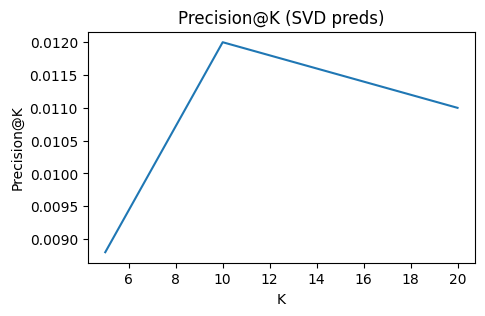

RMSE: 3.4274758464288824 MAE: 3.311629810248786


In [24]:
# Cell 12: suggestions to create charts and save them for report
# Example: precision@K for different K
ks = [5,10,20]
precisions = []
for k in ks:
    precisions.append(precision_at_k(preds_eval, test_r, k=k))

plt.figure(figsize=(5,3))
plt.plot(ks, precisions)
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Precision@K (SVD preds)")
plt.show()

print("RMSE:", rmse_eval, "MAE:", mae_eval)


In [26]:
import os
os.getcwd()


'C:\\Users\\DELL\\Desktop\\Personalized_Recommendation_System\\data'